# Load DPC data files and make top level statistics

In [185]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None 
import pickle

import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from matplotlib.ticker import MultipleLocator

## (2) load duopoly_competition_details.csv![image.png]

In [186]:
df_comp_details14 = pd.read_csv('duopoly_competition_details14.csv')
df_comp_details14['day_played'] = 14


df_comp_details17 = pd.read_csv('duopoly_competition_details17.csv')
df_comp_details17['day_played'] = 17

df_comp_details19 = pd.read_csv('duopoly_competition_details19.csv')
df_comp_details19['day_played'] = 19


moy_3_first14 = (146+131+131)*10/3
df_comp_details14['best_rev'] = moy_3_first14
moy_3_first17 = (425+402+347)*10/3
df_comp_details17['best_rev'] = moy_3_first17
moy_3_first19 = (487+426+423)*10/3
df_comp_details19['best_rev'] = moy_3_first19

df_comp_details = pd.concat([df_comp_details14, df_comp_details17, df_comp_details19], axis=0)
df_comp_details.drop(columns=['errors'], inplace=True)


In [187]:
df_comp_details17['competition_id'].nunique()

4

In [188]:
df_comp_details.groupby('competitor_id').agg({
    'competition_id' : 'nunique',
    'selling_season' : ['max', 'count']
})

competition_id selling_season       
                            nunique            max  count
competitor_id                                            
AwesomeGrasshopper                2            100  20000
FearlessFinch                     2            100  20000
FuturisticSalamander              1            100  10000
HelpfulPython                     2            100  20000
IndigoJackal                      1            100  10000
LittleMarmoset                    3            100  30000
LoutishWorm                       2            100  20000
Winner_2022                       2            100  20000

### create unique selling_season_id

In [189]:
df_comp_details['unique_selling_season_key'] = df_comp_details.apply(lambda r:
                                "%s_%s" % (r.competition_id,r.selling_season), axis=1)

df_comp_details.head(3)

df_comp_details['cum_demand'] = df_comp_details.groupby(['competition_id', 'unique_selling_season_key'])['demand'].cumsum()

#### show revenue distribution over all selling seasons

In [190]:
df_comp_details['revenue'] = df_comp_details['demand'] * df_comp_details['price']
df_comp_details['revenue_standardized'] = df_comp_details['revenue'] / df_comp_details['best_rev']

In [191]:
dfx_rev = df_comp_details.groupby('unique_selling_season_key').agg({
    'revenue_standardized' : 'sum'
}).reset_index()

# dfx_rev['day_played'] = dfx_rev['unique_selling_season_key'].apply(lambda x: int(x.split('_')[0].split('-')[-1]))

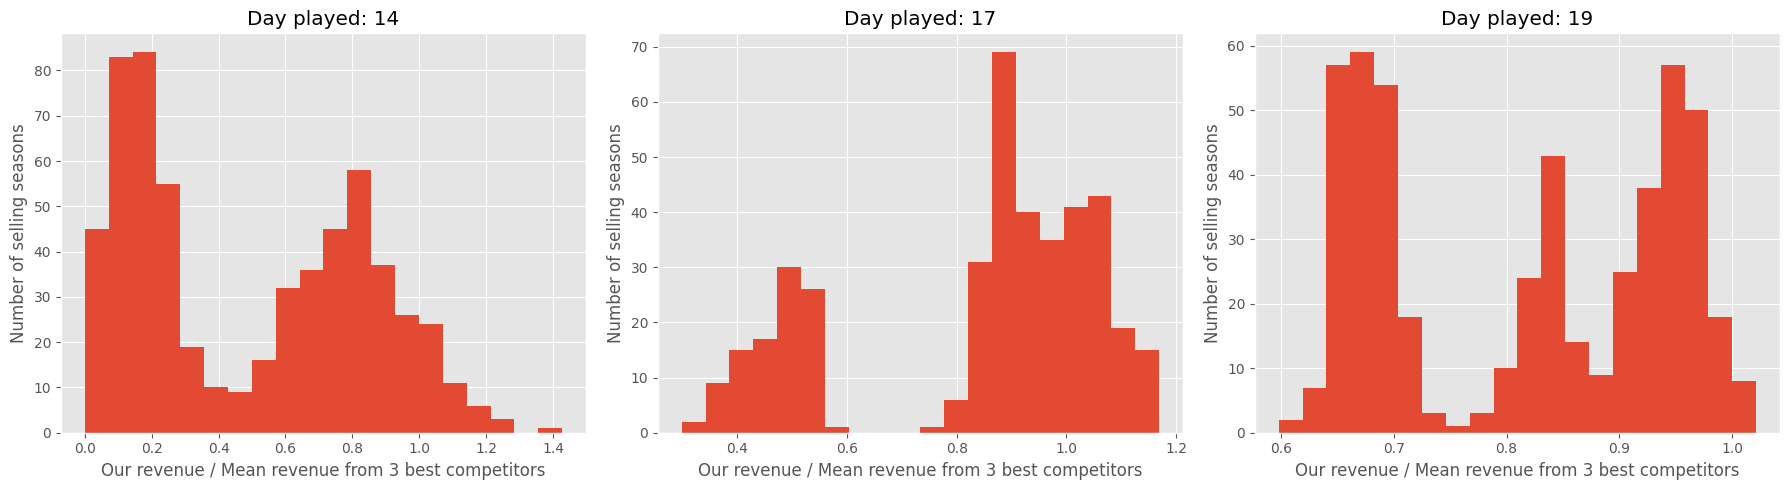

In [192]:
days = [14, 17, 19]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 colonnes pour les 3 jours

for i, day in enumerate(days):
    filtered_df = dfx_rev[dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == day]['unique_selling_season_key']
    )]
    
    # Histogramme pour ce sous-ensemble
    filtered_df.hist(ax=axes[i], bins=20)
    axes[i].set_title(f'Day played: {day}')
    axes[i].set_xlabel('Our revenue / Mean revenue from 3 best competitors')
    axes[i].set_ylabel('Number of selling seasons')

plt.tight_layout()
plt.show()

In [193]:
# Mauvaises saisons pour chaque day_played avec seuils différents
mask_17 = (dfx_rev['revenue_standardized'] > 1) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 17]['unique_selling_season_key']
    )
)

mask_14 = (dfx_rev['revenue_standardized'] > 1) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 14]['unique_selling_season_key']
    )
)

mask_19 = (dfx_rev['revenue_standardized'] > 1) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 19]['unique_selling_season_key']
    )
)

# Combiner avec OR pour capturer toutes les mauvaises saisons
df_good_seasons = dfx_rev[mask_17 | mask_14 | mask_19]

# Détails des bonnes saisons
df_comp_good_seasons = df_comp_details[
    df_comp_details['unique_selling_season_key'].isin(df_good_seasons['unique_selling_season_key'])
]

In [194]:
# Mauvaises saisons pour chaque day_played avec seuils différents
mask_17 = (dfx_rev['revenue_standardized'] < 0.5) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 17]['unique_selling_season_key']
    )
)

mask_14 = (dfx_rev['revenue_standardized'] < 0.4) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 14]['unique_selling_season_key']
    )
)

mask_19 = (dfx_rev['revenue_standardized'] < 0.75) & (
    dfx_rev['unique_selling_season_key'].isin(
        df_comp_details[df_comp_details['day_played'] == 19]['unique_selling_season_key']
    )
)

# Combiner avec OR pour capturer toutes les mauvaises saisons
df_bad_seasons = dfx_rev[mask_17 | mask_14 | mask_19]

# Détails des mauvaises saisons
df_comp_bad_seasons = df_comp_details[
    df_comp_details['unique_selling_season_key'].isin(df_bad_seasons['unique_selling_season_key'])
]
n_selling_season_difficult = df_comp_bad_seasons['unique_selling_season_key'].nunique()
n_competitor_season_difficult = df_comp_bad_seasons['competition_id'].nunique()
# n_season_difficult = df_comp_bad_seasons[''].nunique()
print(f"Number of difficult selling seasons: {n_selling_season_difficult} with {n_competitor_season_difficult} different competitions.")

L_competition_bad = df_comp_bad_seasons['competition_id'].unique()
L_competition_bad_day = df_comp_bad_seasons[['competition_id', 'day_played', 'competitor_id']].drop_duplicates().values.tolist()
print(L_competition_bad_day)


Number of difficult selling seasons: 553 with 6 different competitions.
[['3UDMAq', 14, 'FearlessFinch'], ['3xx6Po', 14, 'HelpfulPython'], ['F3qFhK', 14, 'HelpfulPython'], ['3xpSaU', 17, 'IndigoJackal'], ['3VpvJg', 19, 'LoutishWorm'], ['tkBpSu', 19, 'LittleMarmoset']]


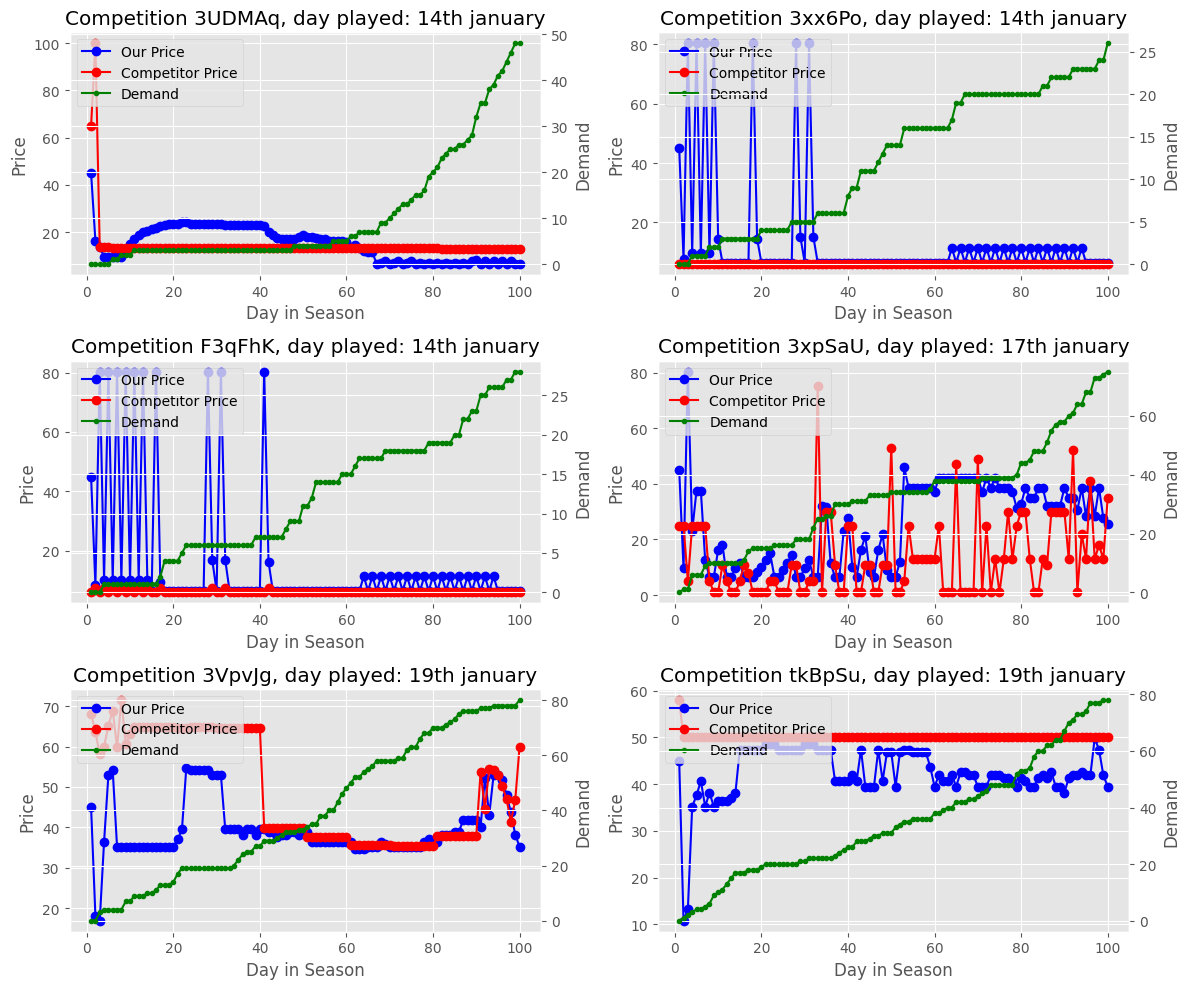

In [195]:
L_bad_competitions = df_comp_bad_seasons['competition_id'].unique().tolist()
# Generer un nombre random entre 1 et 100
import random as rd
selling_season = rd.randint(1, 100)
# Je veux sélectionner une selling_season dans df_comp_bad_seasons au hasard pour chaque competition_id dans L_bad_competitions
df_comp_details_bad_random = pd.DataFrame()
for comp_id in L_bad_competitions:
    df_subset = df_comp_bad_seasons[df_comp_bad_seasons['competition_id'] == comp_id]
    selling_season_random = rd.choice(df_subset['selling_season'].unique().tolist())
    df_selected = df_subset[df_subset['selling_season'] == selling_season_random]
    df_comp_details_bad_random = pd.concat([df_comp_details_bad_random, df_selected], axis=0)

df_comp_details_bad_random.reset_index(drop=True, inplace=True)
df_comp_details_bad_random

plt.figure(figsize=(12, 10))  # taille de la figure

for i, comp in enumerate(L_bad_competitions, start=1):
    plt.subplot(3, 2, i)
    df_plot = df_comp_details_bad_random[df_comp_details_bad_random['competition_id'] == comp]
    
    # Axe principal pour les prix
    ax1 = plt.gca()  # récupère l'axe courant
    ax1.plot(df_plot['selling_period'], df_plot['price'], marker='o', label='Our Price', color='blue')
    ax1.plot(df_plot['selling_period'], df_plot['price_competitor'], marker='o', label='Competitor Price', color='red')
    ax1.set_xlabel('Day in Season')
    ax1.set_ylabel('Price')
    ax1.grid(True)
    
    # Axe secondaire pour la demande
    ax2 = ax1.twinx()  # crée un second axe y partageant le même x
    ax2.plot(df_plot['selling_period'], df_plot['cum_demand'], marker='.', label='Demand', color='green')
    ax2.set_ylabel('Demand')
    
    # Titre et légende combinée
    ax1.set_title(f'Competition {comp}, day played: {df_plot["day_played"].iloc[0]}th january')
    # Légende combinée des deux axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


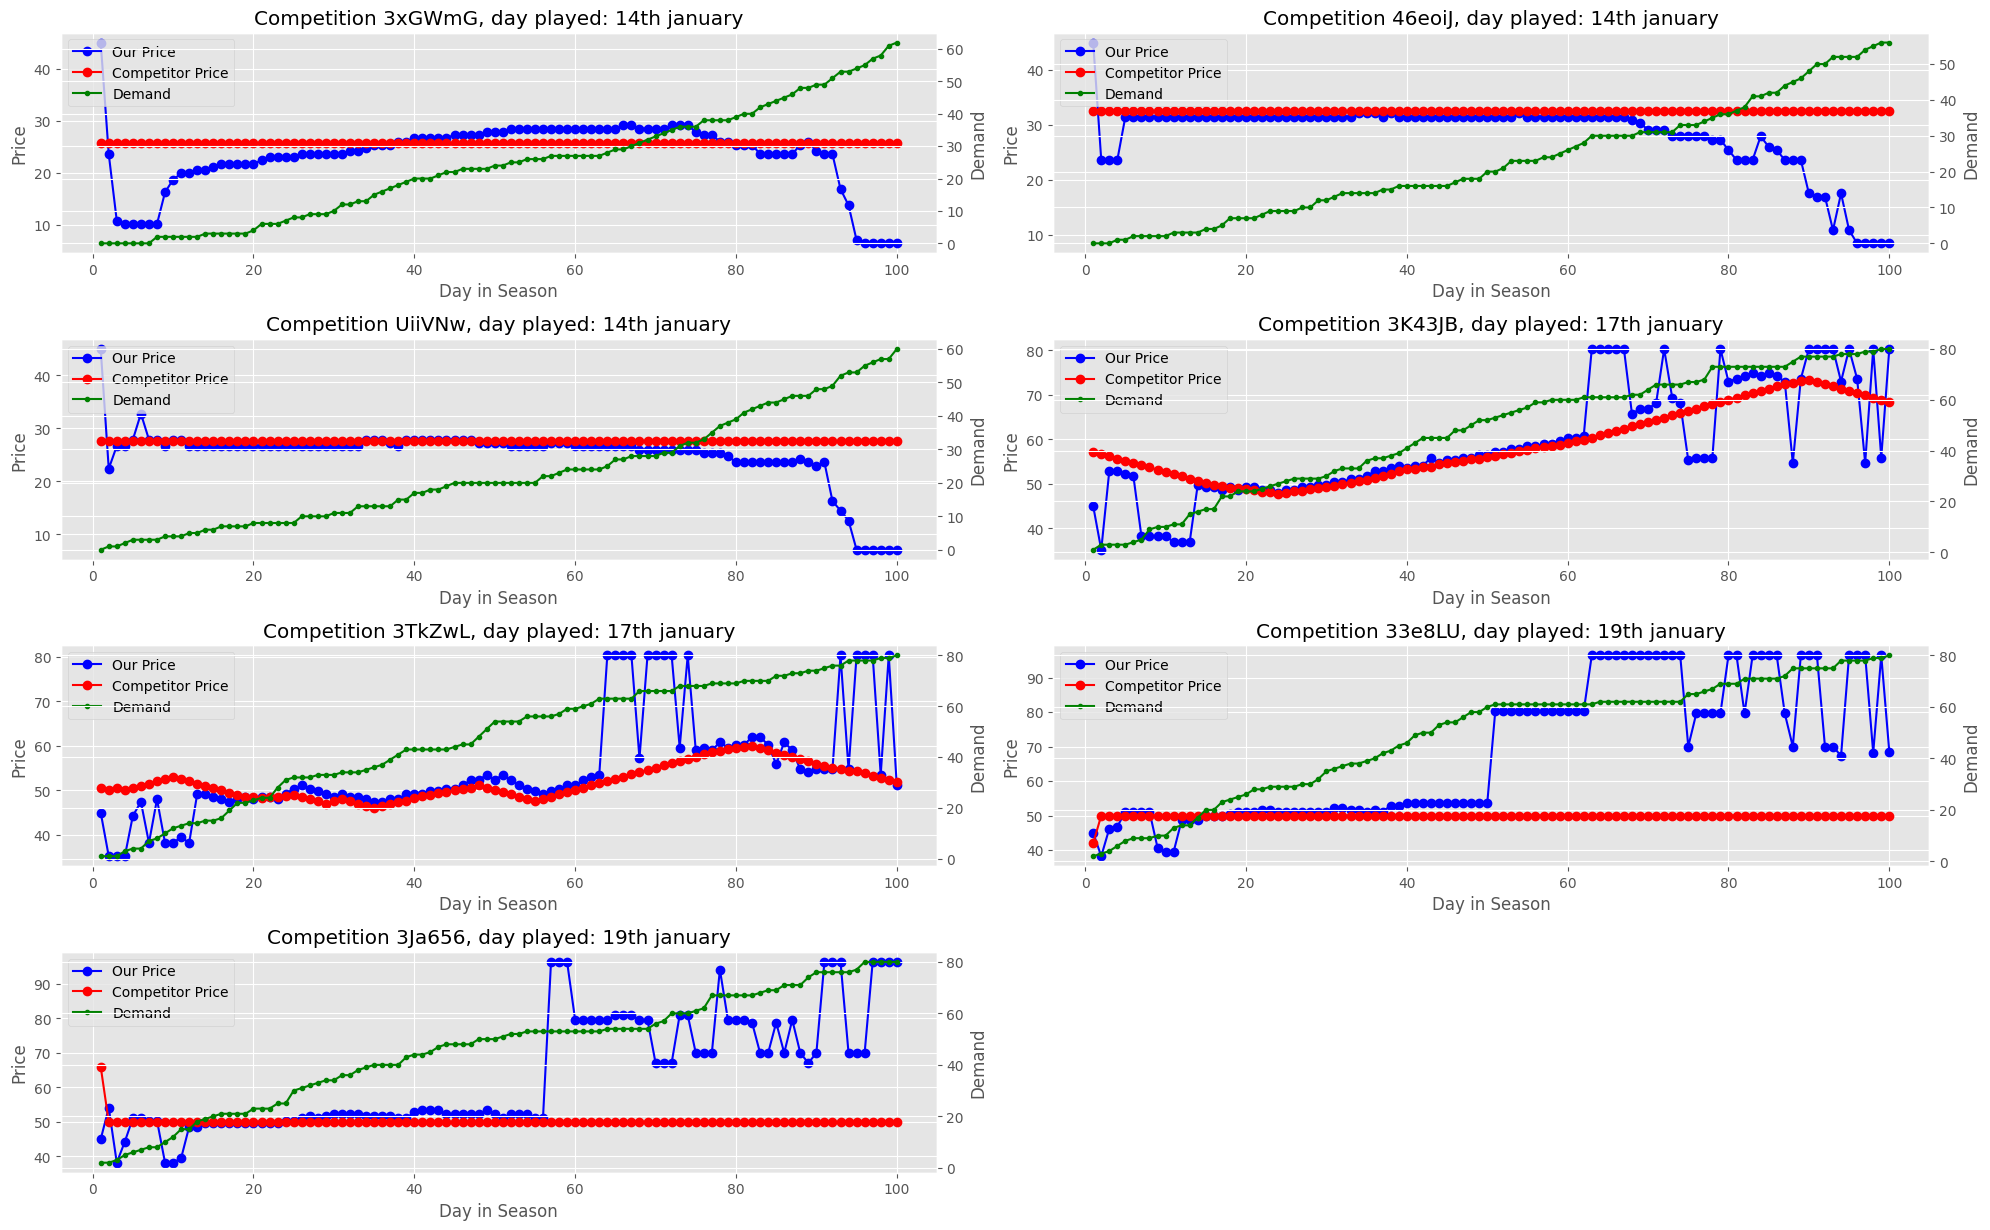

In [196]:
L_good_competitions = df_comp_good_seasons['competition_id'].unique().tolist()

# Je veux sélectionner une selling_season dans df_comp_good_seasons au hasard pour chaque competition_id dans L_good_competitions
df_comp_details_good_random = pd.DataFrame()
for comp_id in L_good_competitions:
    df_subset = df_comp_good_seasons[df_comp_good_seasons['competition_id'] == comp_id]
    selling_season_random = rd.choice(df_subset['selling_season'].unique().tolist())
    df_selected = df_subset[df_subset['selling_season'] == selling_season_random]
    df_comp_details_good_random = pd.concat([df_comp_details_good_random, df_selected], axis=0)

df_comp_details_good_random.reset_index(drop=True, inplace=True)
df_comp_details_good_random

plt.figure(figsize=(20, 15))  # taille de la figure

for i, comp in enumerate(L_good_competitions, start=1):
    plt.subplot(5, 2, i)
    df_plot = df_comp_details_good_random[df_comp_details_good_random['competition_id'] == comp]
    
    # Axe principal pour les prix
    ax1 = plt.gca()  # récupère l'axe courant
    ax1.plot(df_plot['selling_period'], df_plot['price'], marker='o', label='Our Price', color='blue')
    ax1.plot(df_plot['selling_period'], df_plot['price_competitor'], marker='o', label='Competitor Price', color='red')
    ax1.set_xlabel('Day in Season')
    ax1.set_ylabel('Price')
    ax1.grid(True)
    
    # Axe secondaire pour la demande
    ax2 = ax1.twinx()  # crée un second axe y partageant le même x
    ax2.plot(df_plot['selling_period'], df_plot['cum_demand'], marker='.', label='Demand', color='green')
    ax2.set_ylabel('Demand')
    
    # Titre et légende combinée
    ax1.set_title(f'Competition {comp}, day played: {df_plot["day_played"].iloc[0]}th january')
    # Légende combinée des deux axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
df_comp_details['mean_price_so_far'] = df_comp_details.groupby('unique_selling_season_key')['price'].cumsum()
df_comp_details['mean_price_so_far'] = df_comp_details['mean_price_so_far'] / df_comp_details['selling_period']

df_comp_details_comp_no_cap = df_comp_details[df_comp_details['competitor_has_capacity'] == False]
# df_comp_details_comp_no_cap['use_mean_so_far_boundaries'] = 1 si price = mean_price_so_far 0 sinon
df_comp_details_comp_no_cap['use_mean_so_far_boundaries'] = df_comp_details_comp_no_cap.apply(
    lambda r: 1 if r['price'] == r['mean_price_so_far'] else 0, axis=1
)

print(df_comp_details_comp_no_cap['use_mean_so_far_boundaries'].describe())
df_comp_details_comp_no_cap['use_mean_so_far_boundaries'].value_counts()



count    12702.000000
mean         0.000472
std          0.021730
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: use_mean_so_far_boundaries, dtype: float64


use_mean_so_far_boundaries
0    12696
1        6
Name: count, dtype: int64

In [197]:
dfx_rev_top = dfx_rev.sort_values('revenue', ascending=False)

dfx_rev_top.head(10)

KeyError: 'revenue'

### visualize the results of one selling season

In [ ]:
id = dfx_rev_top['unique_selling_season_key'].values[1]

df_aux = df_comp_details[df_comp_details.unique_selling_season_key==id]
df_aux.head(10)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,best_rev,day_played,unique_selling_season_key,revenue
800,33e8LU,9,1,LittleMarmoset,34.0,45.0,2,True,0.001,2228.666667,19,33e8LU_9,90.0
801,33e8LU,9,2,LittleMarmoset,50.0,37.6,2,True,0.162,2228.666667,19,33e8LU_9,75.2
802,33e8LU,9,3,LittleMarmoset,50.0,46.8,1,True,0.121,2228.666667,19,33e8LU_9,46.8
803,33e8LU,9,4,LittleMarmoset,50.0,50.4,2,True,0.109,2228.666667,19,33e8LU_9,100.8
804,33e8LU,9,5,LittleMarmoset,50.0,51.1,2,True,0.117,2228.666667,19,33e8LU_9,102.2
805,33e8LU,9,6,LittleMarmoset,50.0,51.1,0,True,0.110,2228.666667,19,33e8LU_9,0.0
806,33e8LU,9,7,LittleMarmoset,50.0,51.1,1,True,0.120,2228.666667,19,33e8LU_9,51.1
807,33e8LU,9,8,LittleMarmoset,50.0,51.1,0,True,0.112,2228.666667,19,33e8LU_9,0.0
808,33e8LU,9,9,LittleMarmoset,50.0,40.7,0,True,0.152,2228.666667,19,33e8LU_9,0.0
809,33e8LU,9,10,LittleMarmoset,50.0,39.5,3,True,0.157,2228.666667,19,33e8LU_9,118.5


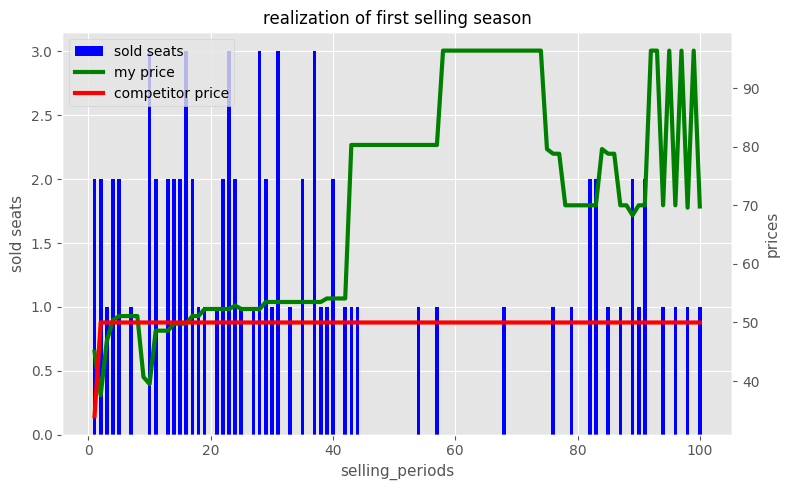

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(df_aux.selling_period, df_aux.demand, color='b', width=0.6, align='center', label = 'sold seats')
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("sold seats" , size=11)

ax_2 = ax.twinx()
ax_2.grid(False)
ax_2.plot(df_aux.selling_period, df_aux.price, color='g', linestyle='-', linewidth=3, label = 'my price')
ax_2.plot(df_aux.selling_period, df_aux.price_competitor, color='r', linestyle='-', linewidth=3, label = 'competitor price')
ax_2.tick_params(axis="both", labelsize=10)
ax_2.set_ylabel("prices" , size=11)

ax.tick_params(axis="both", labelsize=10)
ax.set_title("realization of first selling season", size=12)

# legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_2.get_legend_handles_labels()
ax_2.legend(lines + lines2, labels + labels2, loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

# Plot the Capacity Utilization Curve

**capacity utilization = sold quantity / capacity**

In [ ]:
df_aux['cum_demand'] = df_aux['demand'].cumsum()
df_aux['cap_util'] = round(df_aux[ 'cum_demand'] / 80 ,2)
df_aux.tail(5)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,best_rev,day_played,unique_selling_season_key,revenue,cum_demand,cap_util
895,33e8LU,9,96,LittleMarmoset,50.0,70.0,1,False,0.086,2228.666667,19,33e8LU_9,70.0,78,0.98
896,33e8LU,9,97,LittleMarmoset,50.0,96.4,0,False,0.004,2228.666667,19,33e8LU_9,0.0,78,0.98
897,33e8LU,9,98,LittleMarmoset,50.0,69.6,1,False,0.091,2228.666667,19,33e8LU_9,69.6,79,0.99
898,33e8LU,9,99,LittleMarmoset,50.0,96.4,0,False,0.008,2228.666667,19,33e8LU_9,0.0,79,0.99
899,33e8LU,9,100,LittleMarmoset,50.0,69.8,1,False,0.097,2228.666667,19,33e8LU_9,69.8,80,1.00


In [ ]:
df_aux.competitor_has_capacity.value_counts()


competitor_has_capacity
True     57
False    43
Name: count, dtype: int64

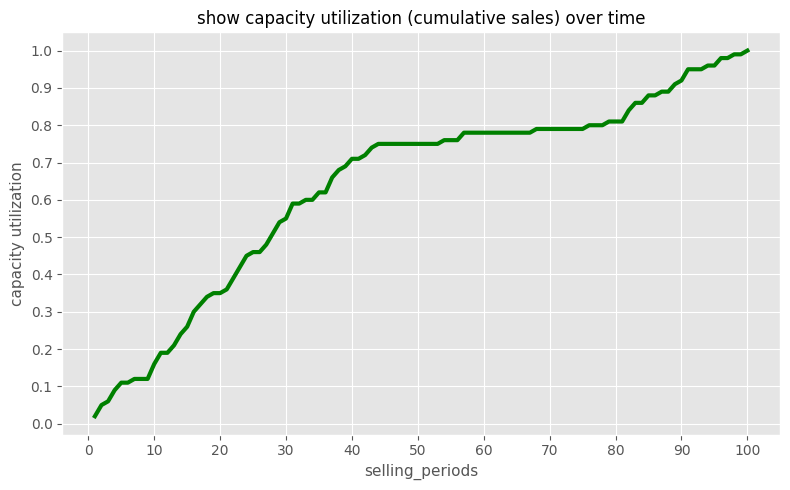

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

# ax.plot(df_aux.selling_period, df_aux.cum_demand, color='b', 
#        width=0.6, align='center', label = 'sold seats')
ax.plot(df_aux.selling_period, df_aux.cap_util, color='g', 
        linestyle='-', linewidth=3, label = 'capacity utilization')
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(0.1)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("show capacity utilization (cumulative sales) over time", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

<Axes: xlabel='selling_period'>

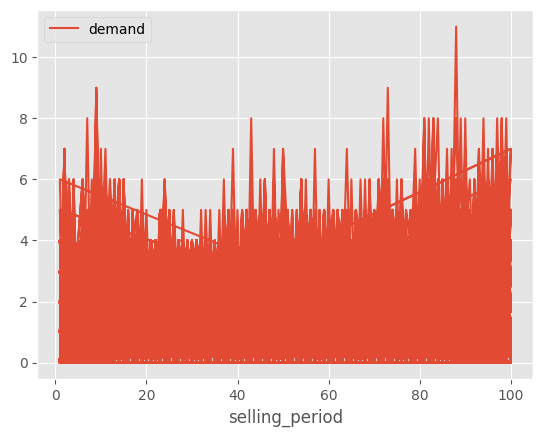

In [ ]:
df_comp_details.plot(x='selling_period', y ='demand')